# (실습) 통계 기초

**참고**

[통계 기초](https://codingalzi.github.io/datapy/from_scratch_2.html)에
정의된 다음 함수들을 활용할 수 있다.

- mean
- median
- quantile
- mode
- data_range
- iqr
- var
- std
- cov
- corrcoef

**필수 모듈**

`matplotlib.pyplot`은 막대그래프, 히스토그램, 산점도 등 데이터를 그래프로 시각화할 때 필요한
다양한 함수를 제공하는 모듈이다.

In [1]:
import matplotlib.pyplot as plt

# 그래프 설정
plt.rc('figure', figsize=(10, 6))  # 그래프 크기 지정

In [3]:
!sudo apt-get install -y fonts-nanum*

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'fonts-nanum-extra' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-coding' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-eco' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum' for glob 'fonts-nanum*'
The following NEW packages will be installed:
  fonts-nanum fonts-nanum-coding fonts-nanum-eco fonts-nanum-extra
0 upgraded, 4 newly installed, 0 to remove and 2 not upgraded.
Need to get 46.0 MB of archives.
After this operation, 177 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-coding all 2.5-3 [4,988 B]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-eco all 1.000-7 [14.7 MB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-extra all 20200506-1 [21.0 

In [4]:
!fc-cache -fv

/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache director

In [5]:
import platform
import matplotlib as mpl

# 윈도우 설정
if platform.system() == 'Windows':
    font_path = "C:/Windows/Fonts/NGULIM.TTF"
    font = mpl.font_manager.FontProperties(fname=font_path).get_name()
    plt.rc('font', family=font)
# 우분투/구글 코랩 설정
elif platform.system() == 'Linux':
    # 우분투/구글코랩의 경우 아래 명령문이 최소 한번 실행되어야 함
    # !sudo apt-get install -y fonts-nanum*
    # !fc-cache -fv

    font = "NanumBarunGothic"
    if not any(map(lambda ft: ft.name == font, mpl.font_manager.fontManager.ttflist)):
        mpl.font_manager.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf")
    plt.rc("font", family=font)
    plt.rc("axes", unicode_minus=False)

## 데이터 준비

영산강에 설치된 승천보에서 측정한 두 개의 데이터셋이다.

- `chl_a`: 녹조 발생의 주요 요인인 클로로필-A의 수치 100개
- `flow`: 보에서 방출되는 시간당 방류량 수치 100개

두 데이터셋의 인덱스는 수질(water quality)을 가리키며,
높은 숫자일 수록 수질은 나쁘다.

In [6]:
# 클로로필-A 수치 100개

chl_a = [51, 51, 53, 53, 54, 55, 57, 57, 59, 60,
         61, 62, 63, 64, 65, 66, 67, 67, 67, 69,
         70, 71, 71, 72, 73, 75, 75, 76, 77, 79,
         81, 81, 83, 83, 85, 86, 87, 88, 88, 88,
         89, 89, 90, 91, 92, 95, 96, 96, 97, 98,
         98, 98, 99, 101, 101, 102, 102, 103, 104, 104,
         104, 104, 105, 106, 107, 108, 110, 111, 111, 112,
         112, 112, 113, 114, 114, 116, 116, 116, 117, 118,
         118, 118, 118, 119, 120, 120, 121, 122, 125, 120,
         121, 121, 121, 122, 122, 122, 122, 124, 125, 124]

In [7]:
# 시간당 방류량 수치 100개

flow = [25, 25, 24, 24, 22, 22, 21, 21, 20, 20,
        19, 19, 19, 18, 18, 18, 17, 17, 17, 16,
        16, 16, 17, 16, 17, 17, 16, 16, 16, 16,
        16, 16, 16, 16, 16, 15, 15, 15, 15, 15,
        15, 14, 15, 14, 14, 13, 13, 13, 13, 13,
        13, 13, 13, 13, 13, 13, 12, 12, 12, 12,
        12, 12, 52, 11, 11, 11, 11, 11, 12, 12,
        12, 12, 12, 11, 12, 12, 12, 11, 11, 11,
        11, 11, 11, 11, 11, 11, 11, 11, 11, 10,
        9, 9, 9, 9, 9, 9, 9, 49, 9, 9]

**문제**

각각의 데이터셋 크기가 100임을 확인하라.

힌트: `len()` 함수

In [12]:
len(flow)

100

In [11]:
len(chl_a)

100

**문제**

가장 높은 클로로필-A의 수치는 얼마인가?

In [13]:
max(chl_a)

125

**문제**

가장 낮은 시간당 방류량 수치는 얼마인가?

In [15]:
min(flow)  #numpy로 하면 flow.min() 가능

9

## 데이터 살펴보기

**문제**

클로로필-A 데이터에 포함된 값들의 빈도를 막대그래프로 그려라.

힌트: `from collections import Counter`

In [17]:
from collections import Counter

x = range(101) #100개

chl_a_cnt = Counter(chl_a)
y = [chl_a_cnt[i] for i in x ]


Text(0, 0.5, '빈도수')

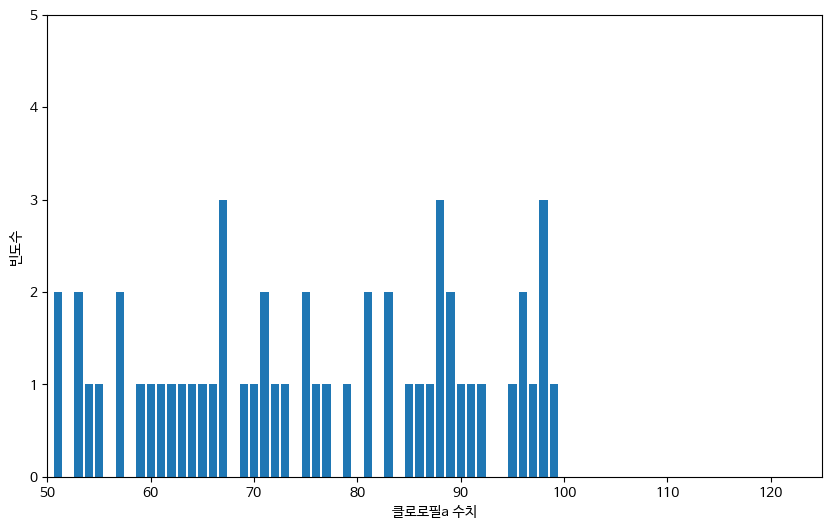

In [20]:
#막대그래프
plt.bar(x, y)
plt.axis([50, 125, 0, 5]) #눈금 x축 50~125 y축 0~5, 이거 없어도 알아서 나옴
plt.xlabel("클로로필a 수치")
plt.ylabel("빈도수")

## 중심 경향성과 평균

**문제**

방류량의 평균값을 계산하라.

In [21]:
import numpy as np
np.mean(flow)

np.float64(14.93)

**문제**

방류량의 중앙값을 계산하라.

In [23]:
np.median(flow)

np.float64(13.0)

**문제**

방류량의 최빈값을 계산하라.

In [ ]:
from scipy import stats
stats.mode(flow)

In [24]:
#판다스 이게 더 많이 쓰임
import pandas as pd
pd.Series(flow).mode()

,0
0,11


**문제**

방류량의 제1, 제3 사분위수를 계산하라.

In [25]:
np.quantile(flow, [0.25, 0.75])

array([11., 16.])

## 산포도와 분산

**문제**

클로로필-A 데이터의 범위를 계산하라.

In [26]:
np.max(chl_a) - np.min(chl_a)

np.int64(74)

**문제**

클로로필-A 데이터의 분산을 계산하라.

In [29]:
np.var(chl_a)

np.float64(506.8004000000001)

**문제**

클로로필-A 데이터의 표준편차를 계산하라.

In [30]:
np.cov(chl_a,flow)

array([[511.91959596, -66.88868687],
       [-66.88868687,  40.6920202 ]])

## 선형 상관관계

**문제**

클로로필-A와 시간당 방류량 사이의 공분산을 계산하고
두 데이터 사이의 상관관계를 설명하라.

In [31]:
np.corrcoef(chl_a, flow) #자기자신을 비교했기 때문에 1 나옴

array([[ 1.       , -0.4634439],
       [-0.4634439,  1.       ]])

**문제**

클로로필-A와 시간당 방류량 사이의 피어슨 상관계수를 계산하고
두 데이터 사이의 선형 상관관계를 설명하라.

In [56]:
np.corrcoef(chl_a, flow)

array([[ 1.       , -0.4634439],
       [-0.4634439,  1.       ]])

클로로필-A 데이터의 범위를 계산하라.

In [34]:
np.int64(74)

np.int64(74)

## 이상치

**산점도**

x축을 방류량, y축을 클로로필-A 수치로 지정한 다음 산점도를 그려보자.

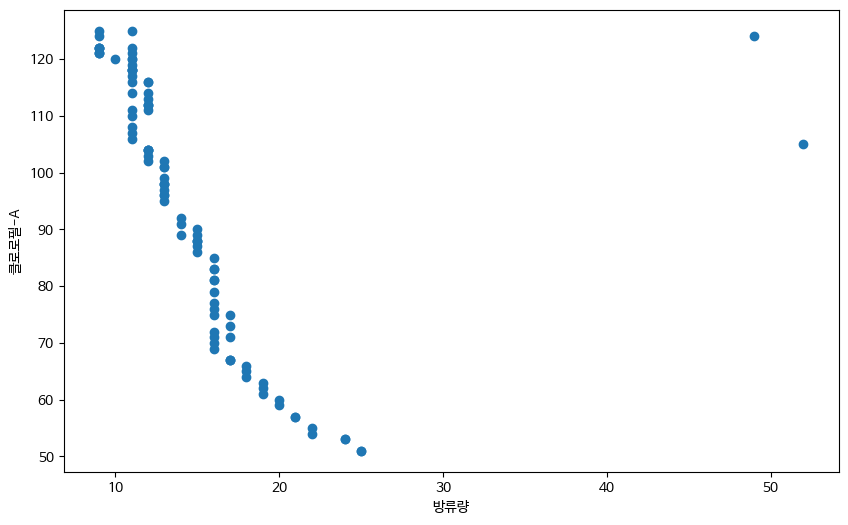

In [35]:
plt.scatter(flow, chl_a)

# 그래프 설정
plt.xlabel("방류량")           # x축 눈금 설명
plt.ylabel("클로로필-A")       # y축 눈금 설명
plt.show()

**문제**

위 산점도에 따르면 두 개의 이상치가 존재한다.
어떤 데이터가 이상치인지 설명하라.

**문제**

클로로필-A 데이터와 방수량 두 데이터셋 모두에서
이상치에 해당하는 두 개의 값을 제거한다.

In [57]:
# None을 적절한 표현식으로 대체할 것.
flow_over40 = []
for i in range(len(chl_a)):
  if flow[i] > 40:
        flow_over40.append(i)
print('이상치 갯수: ', len(flow_over40))
print('방류량 이상치 값: ', flow_over40)

new_chl_a = []
for i in range(len(chl_a)):
  #이 코드랑 아래 not in 코드랑 같은 말
  if i in flow_over40:
    continue
  new_chl_a.append(chl_a[i])

print(len(new_chl_a)) #이상치 값을 제거한 정제 데이터 갯수

이상치 갯수:  2
방류량 이상치 값:  [62, 97]
98


In [50]:
# None을 적절한 표현식으로 대체할 것.

new_flow = []

for i in range(len(flow)):
  if i not in flow_over40:
    new_flow.append(flow[i])

print(len(new_flow))

98


이상치를 제거한 두 데이터셋을 이용하여 산점도를 다시 그려라.

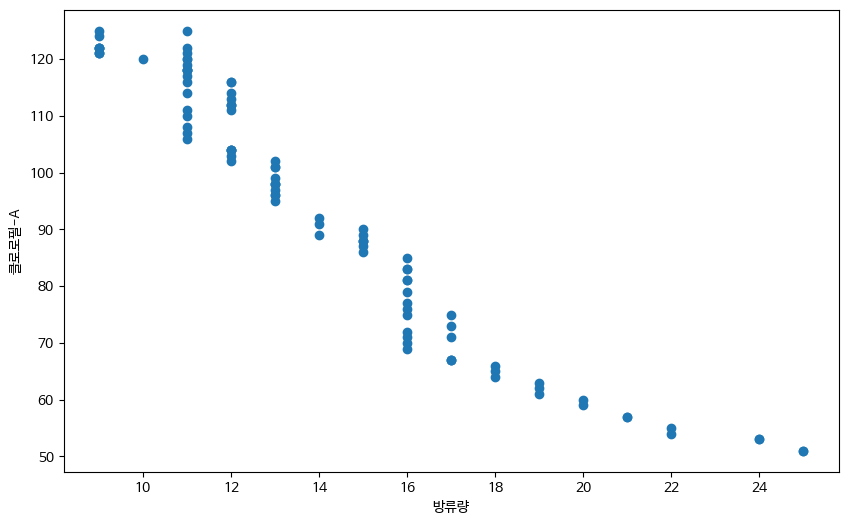

In [51]:
plt.scatter(new_flow, new_chl_a)

# 그래프 설정
plt.xlabel("방류량")           # x축 눈금 설명
plt.ylabel("클로로필-A")       # y축 눈금 설명
plt.show()

**문제**

이상치를 제거하기 이전과 이후의 데이터셋을 이용하여 아래 값들이 어떻게 달라졌는지 설명하라.

- 평균값, 중앙값, 최빈값
- 범위, 사분범위, 분산, 표준편차
- 공분산, 피어슨 상관계수

In [47]:
np.mean(chl_a), np.mean(new_chl_a)

(np.float64(93.86), np.float64(93.43877551020408))

In [53]:
np.mean(flow), np.mean(new_flow)

(np.float64(14.93), np.float64(14.204081632653061))

In [54]:
#중앙값
np.median(chl_a), np.median(new_chl_a)

(np.float64(98.0), np.float64(97.5))

In [55]:
#중앙값
np.median(flow), np.median(new_flow)

(np.float64(13.0), np.float64(13.0))